In [1]:
import pandas as pd

In [2]:
data=pd.read_csv('insurance.csv')

In [4]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# 1. Display Top 5 Rows of The Dataset

In [6]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 2. Check Last 5 Rows of The Dataset

In [7]:
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


# 3. Find Shape of Our Dataset (Number of Rows And Number of Columns)

In [6]:
data.shape

(1338, 7)

In [7]:
print("Number of Rows",data.shape[0])
print("Number of Columns",data.shape[1])

Number of Rows 1338
Number of Columns 7


# 4. Get Information About Our Dataset Like Total Number Rows, Total Number of Columns, Datatypes of Each Column And Memory Requirement

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# 5. Check Null Values In The Dataset

In [9]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# 6. Get Overall Statistics About The Dataset

In [10]:
data.duplicated().any()

True

# 7. Covert Columns From String ['sex','smoker', 'region' ] To Numerical Values

In [11]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
data['sex'].unique()

array(['female', 'male'], dtype=object)

In [3]:
data['sex']=data['sex'].map({'female':0,'male':1})

In [14]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [4]:
data['smoker']=data['smoker'].map({'yes':0,'no':1})

In [16]:
data['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [5]:
data['region']=data['region'].map({'southwest':1,'southeast':2,'northwest':3,'northeast':4})

In [18]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,0,1,16884.92400
1,18,1,33.770,1,1,2,1725.55230
2,28,1,33.000,3,1,2,4449.46200
3,33,1,22.705,0,1,3,21984.47061
4,32,1,28.880,0,1,3,3866.85520


# 8. Store Feature Matrix In X and Response(Target) In Vector y

In [19]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [6]:
# lets store independent variable
X = data.drop(['charges'],axis=1)
X

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,0,1
1,18,1,33.770,1,1,2
2,28,1,33.000,3,1,2
3,33,1,22.705,0,1,3
4,32,1,28.880,0,1,3
...,...,...,...,...,...,...
1333,50,1,30.970,3,1,3
1334,18,0,31.920,0,1,4
1335,18,0,36.850,0,1,2
1336,21,0,25.800,0,1,1


In [7]:
# lets store dependent variable
y =data['charges']
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

# 9. Train/Test split
- Split data into two-part: a training set and a testing set
- Train the model(s) on the training set
- Test the Model(s) on the Testing set

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [14]:
X_train

,age,sex,bmi,children,smoker,region
560,46,female,19.950,2,no,northwest
1285,47,female,24.320,0,no,northeast
1142,52,female,24.860,0,no,southeast
969,39,female,34.320,5,no,southeast
486,54,female,21.470,3,no,northwest
...,...,...,...,...,...,...
1095,18,female,31.350,4,no,northeast
1130,39,female,23.870,5,no,southeast
1294,58,male,25.175,0,no,northeast
860,37,female,47.600,2,yes,southwest


In [48]:
X_test

,age,sex,bmi,children,smoker,region
764,45,0,25.175,2,1,4
887,36,0,30.020,0,1,3
890,64,0,26.885,0,0,3
1293,46,1,25.745,3,1,3
259,19,1,31.920,0,0,3
...,...,...,...,...,...,...
109,63,1,35.090,0,0,2
575,58,0,27.170,0,1,3
535,38,1,28.025,1,1,4
543,54,0,47.410,0,0,2


# 10. Import the models

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# 11. Model Training

In [11]:
lr = LinearRegression()
lr.fit(X_train,y_train)
svm= SVR ()
svm.fit(X_train,y_train)
rf=RandomForestRegressor()
rf.fit(X_train,y_train)
gr= GradientBoostingRegressor()
gr.fit(X_train,y_train)

GradientBoostingRegressor()

In [27]:
print('intercept:',lr.intercept_)
print('coefficient:',lr.coef_)

intercept: 10616.074464780939
coefficient: [ 2.57056264e+02 -1.87914567e+01  3.35781491e+02  4.25091456e+02
 -2.36478181e+04  2.71284266e+02]


# 12. Prediction on Test Data

In [12]:
y_pred1=lr.predict(X_test)
y_pred2=svm.predict(X_test)
y_pred3=rf.predict(X_test)
y_pred4=gr.predict(X_test)

df1=pd.DataFrame({'Actual':y_test,'Lr':y_pred1,'svm':y_pred2,'rf':y_pred3,'gr':y_pred4})
df1

,Actual,Lr,svm,rf,gr
764,9095.06825,8924.407244,9548.095432,11048.360098,11001.128629
887,5272.17580,7116.295018,9492.005195,5282.774705,5840.174656
890,29330.98315,36909.013521,9649.076063,28442.947243,28001.980112
1293,9301.89355,9507.874691,9554.920417,10232.149096,9745.291602
259,33750.29180,27013.350008,9419.697424,34464.739134,33639.100981
...,...,...,...,...,...
109,47055.53210,39116.968669,9649.235457,47532.424341,45431.423211
575,12222.89830,11814.555568,9625.696314,12589.045173,12465.025294
535,6067.12675,7638.107736,9503.727718,6478.329098,6974.336525
543,63770.42801,40959.081722,9605.106753,46530.287953,47862.047791


# 13. Compare Performance Visually

In [29]:
import matplotlib.pyplot as plt

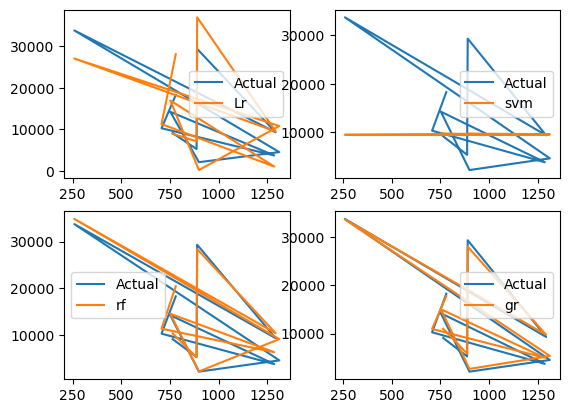

In [30]:
plt.subplot(221)
plt.plot(df1['Actual'].iloc[0:11],label='Actual')
plt.plot(df1['Lr'].iloc[0:11],label='Lr')
plt.legend()

plt.subplot(222)
plt.plot(df1['Actual'].iloc[0:11],label='Actual')
plt.plot(df1['svm'].iloc[0:11],label='svm')
plt.legend()

plt.subplot(223)
plt.plot(df1['Actual'].iloc[0:11],label='Actual')
plt.plot(df1['rf'].iloc[0:11],label='rf')
plt.legend()

plt.subplot(224)
plt.plot(df1['Actual'].iloc[0:11],label='Actual')
plt.plot(df1['gr'].iloc[0:11],label='gr')
plt.legend()



# 14. Evaluating the Algorithm

In [31]:
from sklearn import metrics

In [32]:
# coeff of dett
# goodness of fit
score1 = metrics.r2_score(y_test,y_pred1)
score2 = metrics.r2_score(y_test,y_pred2)
score3 = metrics.r2_score(y_test,y_pred3)
score4 = metrics.r2_score(y_test,y_pred4)

In [33]:
print(score1,score2,score3,score4)

0.7833463107364539 -0.07229022268882468 0.8635333110832424 0.8779936181637191


In [34]:
s1=metrics.mean_absolute_error(y_test,y_pred1)
s2=metrics.mean_absolute_error(y_test,y_pred2)
s3=metrics.mean_absolute_error(y_test,y_pred3)
s4=metrics.mean_absolute_error(y_test,y_pred4)

In [35]:
print(s1,s2,s3,s4)

4186.508898366433 8592.173599203325 2472.5663447050383 2447.1671587151354


In [36]:
mse1=metrics.mean_squared_error(y_test,y_pred1)
mse2=metrics.mean_squared_error(y_test,y_pred2)
mse3=metrics.mean_squared_error(y_test,y_pred3)
mse4=metrics.mean_squared_error(y_test,y_pred4)

In [37]:
print(mse1,mse2,mse3,mse4)

33635210.431178406 166471696.86347133 21186280.345209084 18941336.013983566


# 15. Predict Charges For New Customer

In [38]:
df = {'age':40,'sex':1,'bmi':40.30,'children':4,'smoker':1,'region':3}

data1= pd.DataFrame(df,index=[0])
data1

,age,sex,bmi,children,smoker,region
0,40,1,40.3,4,1,3


In [39]:
new_pred= gr.predict(data1)
print(new_pred)

[10657.72349185]


# 16. Save Model Using Joblib

In [13]:
gr = GradientBoostingRegressor()
gr.fit(X,y)

GradientBoostingRegressor()

In [14]:
import joblib

In [16]:
joblib.dump(gr,'model_joblib_gr1')

['model_joblib_gr1']

In [43]:
model = joblib.load('model_joblib_gr')

In [44]:
model.predict(data1)

array([9696.2573707])

# 17. GUI

In [45]:
from tkinter import *

In [46]:
import joblib

In [17]:
from tkinter import *
import joblib

def show_entry():
    p1= float(e1.get())
    p2= float(e2.get())
    p3= float(e3.get())
    p4= float(e4.get())
    p5= float(e5.get())
    p6= float(e6.get())
    
    model =joblib.load('model_joblib_gr')
    result=model.predict([[p1,p2,p3,p4,p5,p6]])
    
    Label(master,text='Insurance Cost').grid(row=8)
    Label(master, text=result).grid(row=9)


master = Tk()
master.title("Insurance Cost Prediction")
label = Label(master,text ="Insurance Cost Prediction", bg='black',fg='white').grid(row=0,columnspan=2)

Label(master,text="Enter Your Age").grid(row=1)
Label(master,text="Male or Female [1/0]").grid(row=2)
Label(master,text='Enter Your BMI Value').grid(row=3)
Label(master,text='Enter Number of Children').grid(row=4)
Label(master,text='Smoker Yes/No [1/0]').grid(row=5)
Label(master,text='Region [1-4]').grid(row=6)

e1= Entry(master)
e2= Entry(master)
e3= Entry(master)
e4= Entry(master)
e5= Entry(master)
e6= Entry(master)

e1.grid(row=1,column=1)
e2.grid(row=2,column=1)
e3.grid(row=3,column=1)
e4.grid(row=4,column=1)
e5.grid(row=5,column=1)
e6.grid(row=6,column=1)

Button(master,text='Predict',command=show_entry).grid()

mainloop()

Exception in Tkinter callback
Traceback (most recent call last):
  File "C:\Users\DELL\anaconda31\Lib\tkinter\__init__.py", line 1948, in __call__
    return self.func(*args)
           ^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\AppData\Local\Temp\ipykernel_8304\3152463131.py", line 12, in show_entry
    model =joblib.load('model_joblib_gr')
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda31\Lib\site-packages\joblib\numpy_pickle.py", line 650, in load
    with open(filename, 'rb') as f:
         ^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'model_joblib_gr'
Exception in Tkinter callback
Traceback (most recent call last):
  File "C:\Users\DELL\anaconda31\Lib\tkinter\__init__.py", line 1948, in __call__
    return self.func(*args)
           ^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\AppData\Local\Temp\ipykernel_8304\3152463131.py", line 12, in show_entry
    model =joblib.load('model_joblib_gr')
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  